In [4]:
#5.2
import numpy as np

s = [[1, 2], [3, 4], [1, 2], [3, 4], [1, 2], [3, 4], [1, 2], [3, 4], [1, 2], [3, 4]]

name = input("name of file:")


np.savetxt(name, s)
data = np.loadtxt(name, comments='#')

x=data[:,0]
y=data[:,1]

xmin = np.min(x)
ymin=np.min(y)

xmax=np.max(x)
ymax=np.max(y)

xmean=np.mean(x)
ymean=np.mean(y)



y2=(y-ymean)**2

print(f"x list:{x}, y list:{y}")
print()
print(f"x min:{xmin},    y min:{ymin}, x max:{xmax},   y max:{ymax},    x mean:{xmean},    y mean:{ymean}")
print()
print(f"y2 list:{y2}")




name of file:data.txt
x list:[1. 3. 1. 3. 1. 3. 1. 3. 1. 3.], y list:[2. 4. 2. 4. 2. 4. 2. 4. 2. 4.]

x min:1.0,    y min:2.0, x max:3.0,   y max:4.0,    x mean:2.0,    y mean:3.0

y2 list:[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [26]:
#5.6


import numpy as np

a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

print(np.concatenate((a,b)))
#shape is 1x6

a = np.array([[1, 2], [3, 4]])
b = np.array([[5, 6], [7, 8]])


#q1 has two 1x3 arrays whereas q2 has two 2x2 matrices

print( np.concatenate((a, b)))
print( np.concatenate((a, b), axis=0))
print(np.concatenate((a, b), axis=1))

#first two are the same; one 4x2 matrix.  
#The second one is a 2x4 matrix which consists of both matrices combined side by side

[1 2 3 4 5 6]
[[1 2]
 [3 4]
 [5 6]
 [7 8]]
[[1 2]
 [3 4]
 [5 6]
 [7 8]]
[[1 2 5 6]
 [3 4 7 8]]


/tmp/ipykernel_18045/1856171365.py:6: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  m101 = imread("./m101BW.jpg")  #defines m101


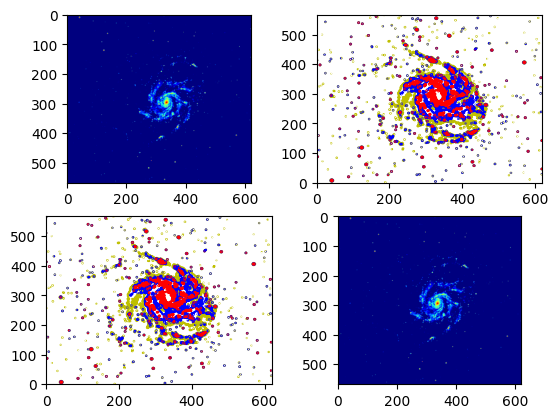

In [12]:
#5.9
#import imageio.v2 as imageio   <-- is this important?
from imageio import imwrite, imread
from matplotlib.pyplot import subplots, show

m101 = imread("./m101BW.jpg")  #defines m101

imwrite('m101BW.jpg', m101)  # From now on can use m101BW.jpg instead


threshold = 90
m101_filter = np.where(m101>90, m101, threshold)    #creates the filter for np.where later

    #shorthand so its easier
fig, ax = subplots(2,2)            #positions the image     

ax[0,0].imshow(m101_filter, cmap='jet')         #prints the image with colour filter jet
ax[0,1].contour(m101, levels=np.percentile(m101, [90,95,99]), colors=['y', 'b', 'r'])        #makes contour lines with percentiles as listed 

ax[1,1].imshow(m101_filter, cmap='jet')         #prints the image with colour filter jet
ax[1,0].contour(m101, levels=np.percentile(m101, [90,95,99]), colors=['y', 'b', 'r'])

fig.savefig("test.jpg")

show()    #shows image


In [11]:
#5.12
import numpy as np
import scipy

c = scipy.constants.c

class Galaxy:    
    """Class for redshift calculation of galaxies"""  
        
    caH_0 = 3968.5      # Calcium H line in rest frame
    c=c
    
    def __init__(self, name, calciumHline=caH_0):      
        self.name = name
        self.caH = calciumHline
        
        
    def redshift(self):        
        z = (self.caH - self.caH_0)/self.caH          
        
        return(z)

    def velocity(self):
        v = (self.c*self.redshift())/1000                      #devide my 1000 to make in km/s
        return(v)

gal1 = Galaxy("NGC1832", 3994.7)
print(gal1.velocity())

1966.2458756852695


z profile in the middle of xy plane [0.00482 0.00666 0.00705 0.00889 0.01269 0.02012 0.02789 0.03712 0.03985
 0.04617 0.0606  0.04935 0.02734 0.01746 0.0149  0.0247  0.03478 0.03472
 0.03174 0.02931 0.02995 0.02909 0.02687 0.0247  0.02483 0.02504 0.02486
 0.0228  0.01888 0.01625 0.01589 0.01473 0.01294 0.01236 0.01144 0.01118
 0.01038 0.00848 0.00751 0.0072 ]
for the z profile;   max:0.0606, min:0.00482, median:0.0222885, standard deviation:0.012699434544498428


Text(0, 0.06, 'max: 0.0606, min: 0.00482, median: 0.022288, std: 0.012699')

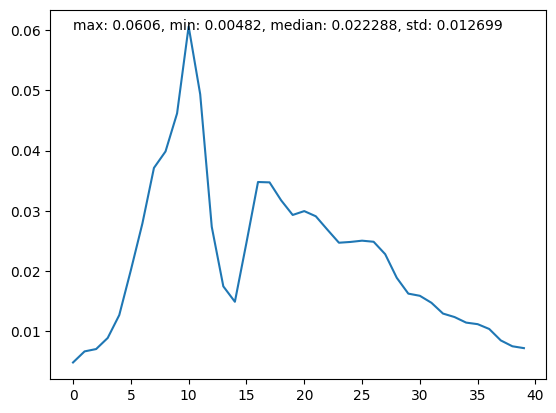

In [18]:
#5.10
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt('ngc6946.txt', comments='#')
arr=data.reshape(40,50,70)     #reshapes data to 40 planes, 50 rows and 70 columns
z_prof = arr[:,25,35]      #:takes all z values, 25&35 are middle xandy values, produces an array of 40 values for each z plane
print("z profile in the middle of xy plane", z_prof)


zmax=np.max(z_prof)
zmin=np.min(z_prof)
zmed=np.mean(z_prof)
zstd=np.std(z_prof)

print(f"for the z profile;   max:{zmax}, min:{zmin}, median:{zmed}, standard deviation:{zstd}")

zr=range(0,40)


plt.plot(zr, z_prof)
plt.annotate(f'max: {zmax}, min: {zmin}, median: {zmed:2f}, std: {zstd:2f}', xy=(0,0.06))

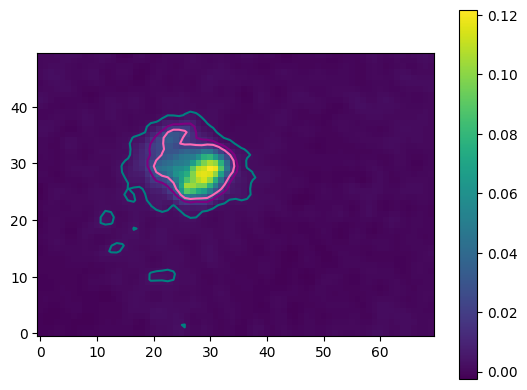

In [2]:
#5.11
import numpy as np
from imageio import imwrite, imread
from matplotlib.pyplot import subplots, show
import matplotlib.pyplot as plt


data = np.loadtxt('ngc6946.txt', comments='#')
arr=data.reshape(40,50,70)

image = arr[0,:,:]   #splice for each dimension seperated by :, follows the same stop start rules

fig, ax = subplots(1,1)


std = np.std(image)
mean = np.mean(image)

mean_1 = mean+std
mean_2 = mean+2*std



plt.imshow(image, origin = 'lower')
plt.colorbar()           #why doesnt this work?
plt.contour(image, levels=[mean, mean_1, mean_2], colors=['teal', 'purple', 'hotpink'], origin='lower')    #because the contour list is transposed without flipping the image(changing the origin) will b flipped
plt.show()


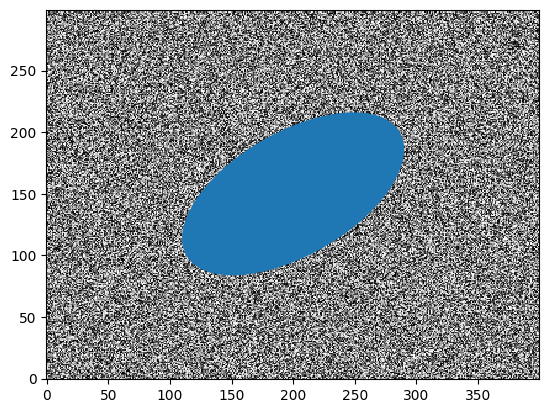

In [2]:
#5.13
import numpy as np
from matplotlib.pyplot import figure, show
import matplotlib.patches
import matplotlib.pyplot as plt


Nx = 400
Ny = 300
data = np.random.random((Ny,Nx))

semi_major=100
semi_minor=50
position_angle=30
xc=400/2
yc=300/2

fig,ax=plt.subplots()

plt.imshow(data, interpolation='none', origin="lower", cmap='gray')

ellipse = matplotlib.patches.Ellipse((xc,yc) ,semi_major*2, semi_minor*2, angle=position_angle)

ax.add_patch(ellipse)


